# Imports

In [ ]:
!pip install -q diffusers transformers accelerate safetensors


In [ ]:
import os, io, zipfile, gc, torch, numpy as np
from PIL import Image, ImageOps
from tqdm.auto import tqdm
from google.colab import files
from diffusers import StableDiffusionXLInpaintPipeline

# Single Go with Image Showing

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving your_mask.png to your_mask.png
Saving your_rgb.png to your_rgb.png


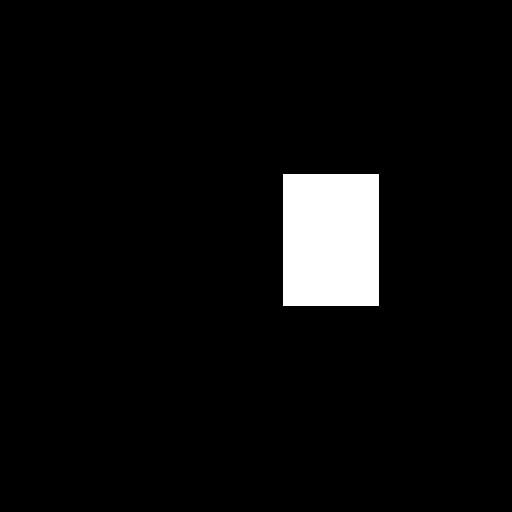

Saved: /content/your_square_mask.png  |  size: 512x512  |  box: (259,150)–(402,329)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

The config attributes {'decay': 0.9999, 'inv_gamma': 1.0, 'min_decay': 0.0, 'optimization_step': 37000, 'power': 0.6666666666666666, 'update_after_step': 0, 'use_ema_warmup': False} were passed to UNet2DConditionModel, but are not expected and will be ignored. Please verify your config.json configuration file.


Input image & mask:


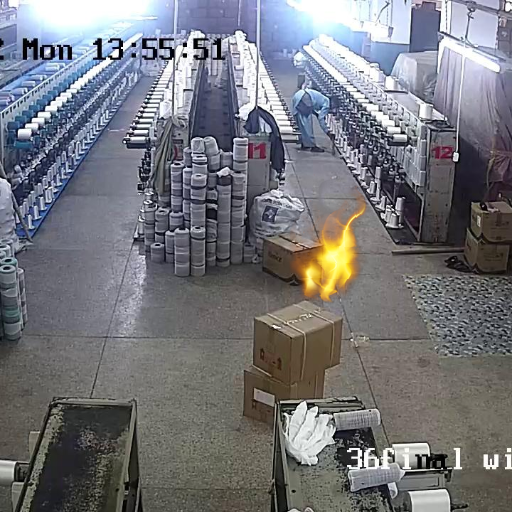

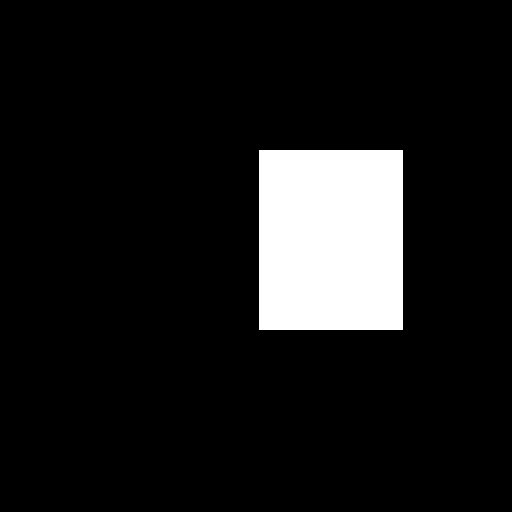

  0%|          | 0/24 [00:00<?, ?it/s]

Saved -> /content/out/your_rgb_inpainted.png
Tight box: (283,174)–(378,305)


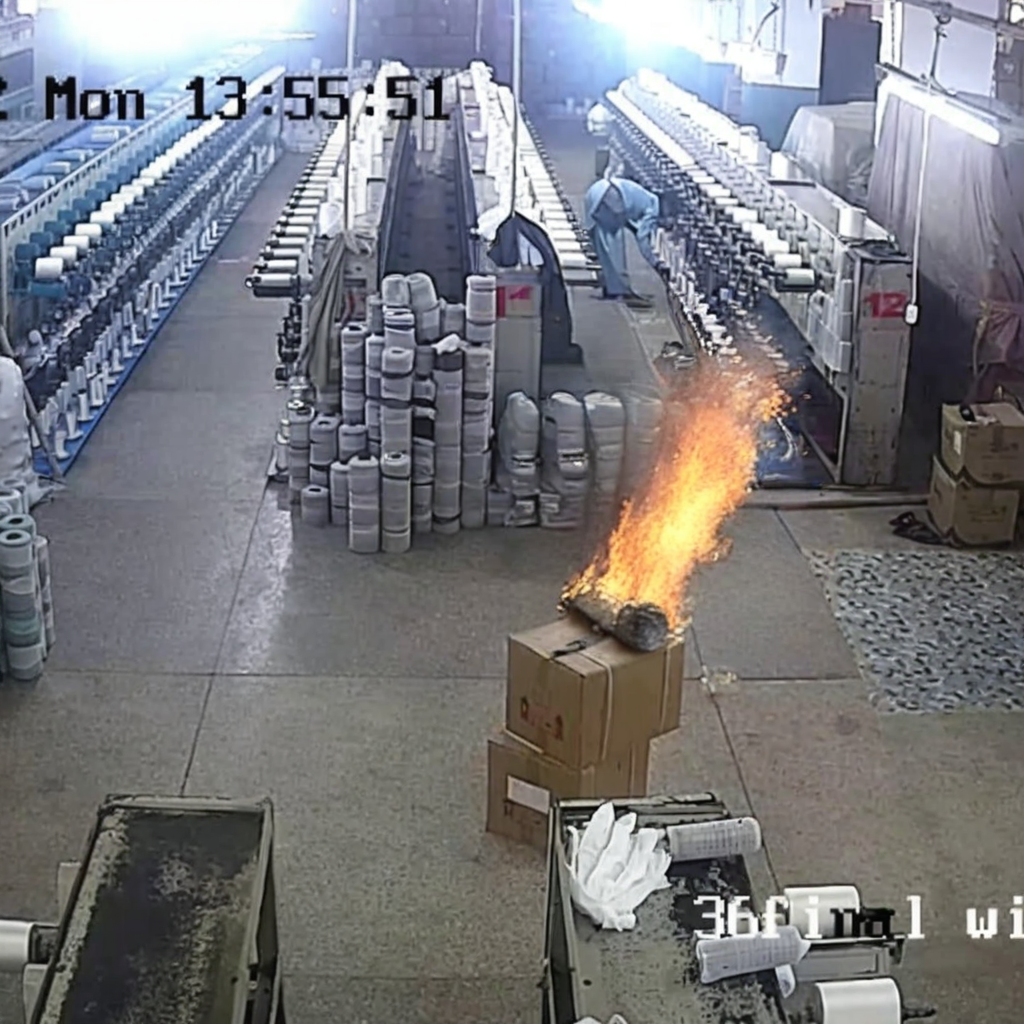

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

The config attributes {'decay': 0.9999, 'inv_gamma': 1.0, 'min_decay': 0.0, 'optimization_step': 37000, 'power': 0.6666666666666666, 'update_after_step': 0, 'use_ema_warmup': False} were passed to UNet2DConditionModel, but are not expected and will be ignored. Please verify your config.json configuration file.


Input image & mask:


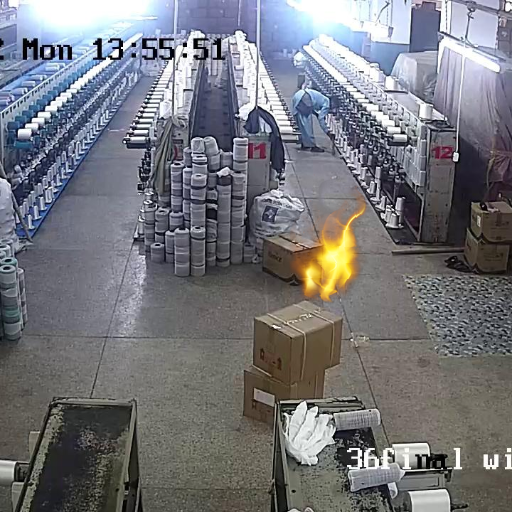

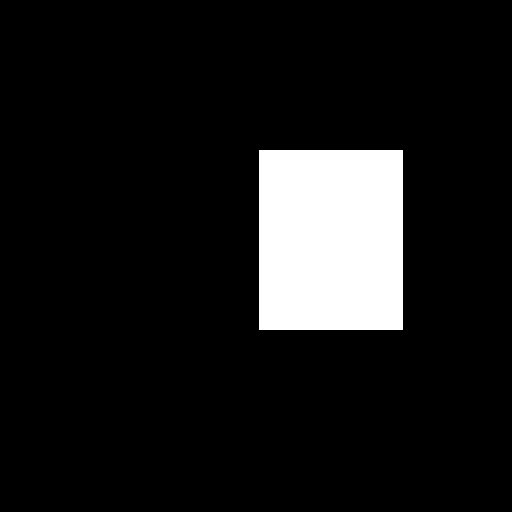

  0%|          | 0/24 [00:00<?, ?it/s]

Saved -> /content/out/your_rgb_inpainted.png


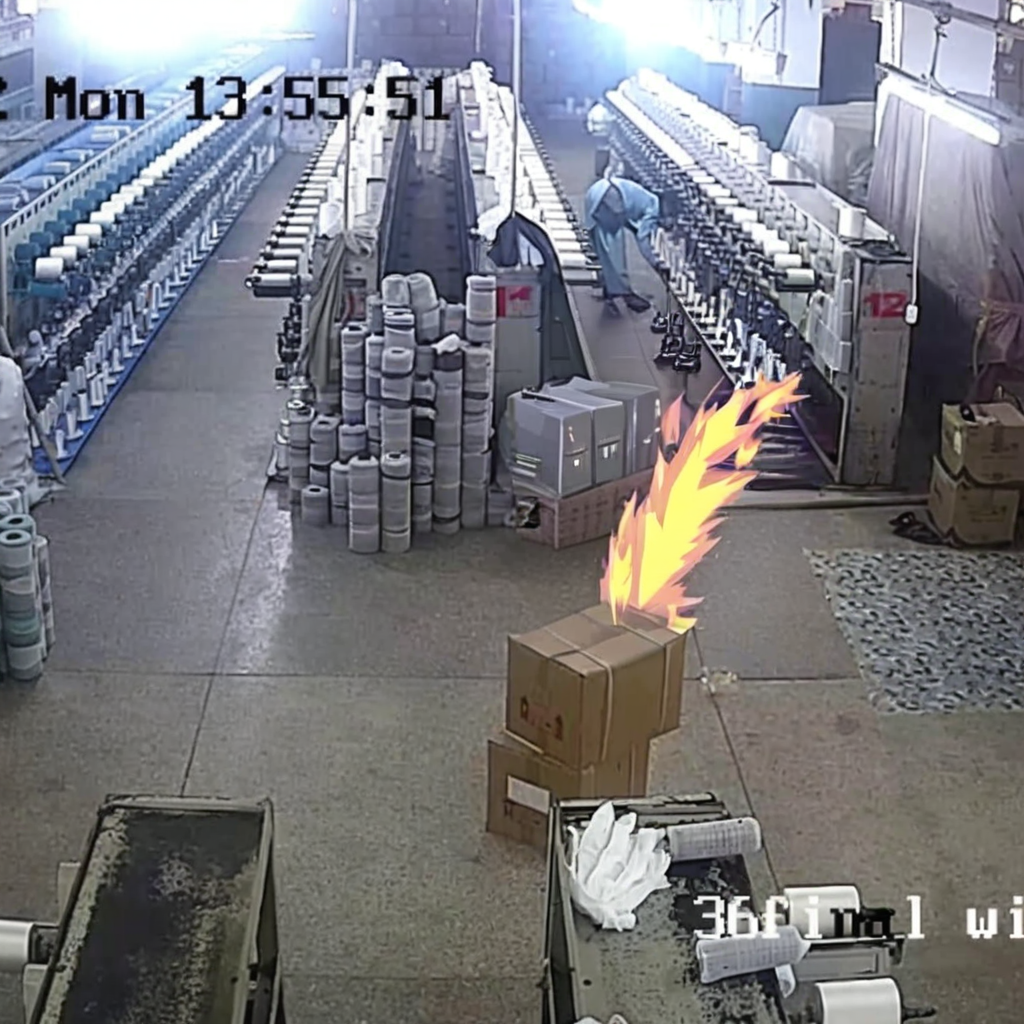

In [ ]:

mask_path = "/content/your_mask.png"              # existing binary mask (white=edit)
square_mask_path = "/content/your_square_mask.png"  # output path

# knobs
padding_px = 24      # extra pixels around the bbox

# load + binarize
m = Image.open(mask_path).convert("L")
arr = np.array(m)
binm = (arr > 127).astype(np.uint8)  # 1 where white, 0 elsewhere

# find bbox of white pixels
ys, xs = np.where(binm == 1)
if len(xs) == 0:
    raise ValueError("No white pixels found in mask; cannot build bbox.")

h, w = binm.shape
x0, x1 = xs.min(), xs.max()
y0, y1 = ys.min(), ys.max()

# show tight bbox mask (before padding)
tight_mask = np.zeros((h, w), dtype=np.uint8)
tight_mask[y0:y1+1, x0:x1+1] = 255
display(Image.fromarray(tight_mask).convert("L"))


# apply padding (clamped to image bounds)
x0 = max(0, x0 - padding_px)
y0 = max(0, y0 - padding_px)
x1 = min(w - 1, x1 + padding_px)
y1 = min(h - 1, y1 + padding_px)


# build new mask
rect_mask = np.zeros((h, w), dtype=np.uint8)
rect_mask[y0:y1+1, x0:x1+1] = 255

# save
os.makedirs(os.path.dirname(square_mask_path), exist_ok=True)
Image.fromarray(rect_mask).save(square_mask_path)
print(f"Saved: {square_mask_path}  |  size: {w}x{h}  |  box: ({x0},{y0})–({x1},{y1})")


# REALISTIC:

# Load SDXL inpaint pipeline
MODEL_ID = "diffusers/stable-diffusion-xl-1.0-inpainting-0.1"
pipe = StableDiffusionXLInpaintPipeline.from_pretrained(
    MODEL_ID, torch_dtype=torch.float16, variant="fp16", use_safetensors=True
).to("cuda")

# paths
image_path = "/content/your_rgb.png"   # background + pasted fire
mask_path  = "/content/your_square_mask.png"  # white = edit, black = keep
out_path   = "/content/out/your_rgb_inpainted.png"
os.makedirs(os.path.dirname(out_path), exist_ok=True)

# Load & make sizes multiples of 8 (no cropping)
def snap8(x): return int(round(x/8)*8)
img  = ImageOps.exif_transpose(Image.open(image_path).convert("RGB"))
mask = ImageOps.exif_transpose(Image.open(mask_path).convert("L"))
W,H = img.size
W8,H8 = snap8(W), snap8(H)
if (W8,H8) != (W,H):
    img  = img.resize((W8,H8), Image.BICUBIC)
    mask = mask.resize((W8,H8), Image.NEAREST)

# show inputs
print("Input image & mask:"); display(img, mask)

# Prompts & settings
prompt = (
    "realistic fire spreading naturally, natural lighting, "
    "orange glow on nearby surfaces, light smoke, subtle heat distortion, "
    "no changes to background"
)
negative_prompt = (
    "neon, cartoon, hard edges, glowing outline, scene changes, extra objects"
)

strength = 0.8       # how much to change inside the mask (0..1)
guidance_scale = 12.0 # prompt adherence; keep moderate to avoid hallucinations
steps = 30
seed = 42
gen = torch.Generator(device="cuda").manual_seed(seed)

# Inpaint
with torch.inference_mode():
    out = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=img,
        mask_image=mask,
        strength=strength,
        guidance_scale=guidance_scale,
        num_inference_steps=steps,
        generator=gen,
    ).images[0]

out.save(out_path)
print("Saved ->", out_path)
print(f"Tight box: ({np.where(binm==1)[1].min()},{np.where(binm==1)[0].min()})–({np.where(binm==1)[1].max()},{np.where(binm==1)[0].max()})")

display(out)

# cleanup
del img, mask, out
gc.collect()
torch.cuda.empty_cache()



# Full Folder Go

In [ ]:
# !pip install -q diffusers transformers accelerate safetensors

import os, re, gc, shutil, zipfile, torch, numpy as np
from PIL import Image, ImageOps
from tqdm.auto import tqdm
from diffusers import StableDiffusionXLInpaintPipeline
from google.colab import drive, files

PADDING_PX   = 24
SEED         = 42
STRENGTH     = 0.8
GUIDANCE     = 12.0
STEPS        = 30
MODEL_ID     = "diffusers/stable-diffusion-xl-1.0-inpainting-0.1"

# Prompts
PROMPT_REAL = (
    "realistic fire spreading naturally, natural lighting, "
    "orange glow on nearby surfaces, light smoke, subtle heat distortion, "
    "no changes to background"
)
NEG_REAL = "neon, cartoon, hard edges, glowing outline, scene changes, extra objects"

PROMPT_UNREAL = (
    "unrealistic, anime fire, neon, cartoon, hard edges, glowing outline, "
    "no changes to background"
)
NEG_UNREAL = "realistic"

def empty_dir(d):
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d, exist_ok=True)

def build_rect_from_mask(mask_img_path, out_path,
                                   padding_px=PADDING_PX):
    # load + binarize
    m = Image.open(mask_img_path).convert("L")
    arr = np.array(m)
    binm = (arr > 127).astype(np.uint8)  # 1=white

    ys, xs = np.where(binm == 1)
    if len(xs) == 0:
        raise ValueError(f"No white pixels in mask: {mask_img_path}")

    h, w = binm.shape
    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()

    # padding (clamped)
    x0 = max(0, x0 - padding_px); y0 = max(0, y0 - padding_px)
    x1 = min(w - 1, x1 + padding_px); y1 = min(h - 1, y1 + padding_px)

    rect_mask = np.zeros((h, w), dtype=np.uint8)
    rect_mask[y0:y1+1, x0:x1+1] = 255

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    Image.fromarray(rect_mask).save(out_path)

def load_pair(img_path, mask_path):

    img  = ImageOps.exif_transpose(Image.open(img_path).convert("RGB"))
    mask = ImageOps.exif_transpose(Image.open(mask_path).convert("L"))
    return img, mask


def list_images_recursive(root):
    out = []
    for dp, _, files in os.walk(root):
        for f in files:
            if f.lower().endswith(".png"):
                out.append(os.path.join(dp, f))
    return out


def key_from_name(path: str):
    stem = os.path.splitext(os.path.basename(path))[0].lower()

    if stem.startswith("rgb_"):
        return stem[len("rgb_"):]
    elif stem.startswith("mask_"):
        return stem[len("mask_"):]
    else:
        return stem


# unzip from Drive
drive.mount('/content/drive')

MASK_DIR    = "/content/masks"
RGB_DIR     = "/content/rgbs"
OUT_MASKS   = "/content/out_square_masks"
OUT_REAL    = "/content/out_realistic"
OUT_UNREAL  = "/content/out_unrealistic"

for d in [MASK_DIR, RGB_DIR, OUT_MASKS, OUT_REAL, OUT_UNREAL]:
    empty_dir(d)

zip_path1 = '/content/drive/MyDrive/fire_controlnet_mask.zip'
zip_path2 = '/content/drive/MyDrive/fire_controlnet_rgb.zip'

with zipfile.ZipFile(zip_path1, 'r') as z: z.extractall(MASK_DIR)
print("Unzipped masks ->", MASK_DIR)
with zipfile.ZipFile(zip_path2, 'r') as z: z.extractall(RGB_DIR)
print("Unzipped rgbs   ->", RGB_DIR)

# collect files & pair
mask_files = list_images_recursive(MASK_DIR)
rgb_files  = list_images_recursive(RGB_DIR)
print(f"Found {len(mask_files)} mask images and {len(rgb_files)} RGB images.")

rgb_map = {key_from_name(p): p for p in rgb_files}

pairs, unmatched = [], []
for mpath in mask_files:
    k = key_from_name(mpath)
    r = rgb_map.get(k)
    (pairs if r else unmatched).append((r, mpath) if r else (os.path.basename(mpath), k))

print(f"Found {len(pairs)} pairs. Unmatched masks: {len(unmatched)}")

# load pipeline once
pipe = StableDiffusionXLInpaintPipeline.from_pretrained(
    MODEL_ID, torch_dtype=torch.float16, variant="fp16", use_safetensors=True
).to("cuda")
if hasattr(pipe, "enable_vae_tiling"): pipe.enable_vae_tiling()
if hasattr(pipe, "enable_attention_slicing"): pipe.enable_attention_slicing()

# run
gen = torch.Generator(device="cuda").manual_seed(SEED)

saved_real = saved_unreal = 0
for rgb_path, mask_path in tqdm(pairs):
    base = os.path.splitext(os.path.basename(rgb_path))[0]

    # build padded mask
    sq_mask_path = os.path.join(OUT_MASKS, f"{base}_square_mask.png")
    try:
        build_rect_from_mask(mask_path, sq_mask_path, PADDING_PX)
    except Exception as e:
        print(f"[skip {base}] mask error: {e}")
        continue

    # load
    img, sqmask = load_pair(rgb_path, sq_mask_path)

    # REALISTIC
    with torch.inference_mode():
        out_real = pipe(
            prompt=PROMPT_REAL,
            negative_prompt=NEG_REAL,
            image=img,
            mask_image=sqmask,
            strength=STRENGTH,
            guidance_scale=GUIDANCE,
            num_inference_steps=STEPS,
            generator=gen,
        ).images[0]
    out_real.save(os.path.join(OUT_REAL, f"{base}_realistic.png"))
    saved_real += 1

    #  UNREALISTIC
    with torch.inference_mode():
        out_unreal = pipe(
            prompt=PROMPT_UNREAL,
            negative_prompt=NEG_UNREAL,
            image=img,
            mask_image=sqmask,
            strength=STRENGTH,
            guidance_scale=GUIDANCE,
            num_inference_steps=STEPS,
            generator=gen,
        ).images[0]
    out_unreal.save(os.path.join(OUT_UNREAL, f"{base}_unrealistic.png"))
    saved_unreal += 1

    # per-iteration cleanup
    del img, sqmask, out_real, out_unreal
    gc.collect()
    torch.cuda.empty_cache()

print(f"Done. Saved {saved_real} realistic and {saved_unreal} unrealistic images.")
print("  Masks  ->", OUT_MASKS)
print("  Real   ->", OUT_REAL)
print("  Unreal ->", OUT_UNREAL)

# zip & download
zip_real   = "/content/sdxl_realistic"
zip_unreal = "/content/sdxl_unrealistic"
shutil.make_archive(zip_real,   "zip", OUT_REAL)
shutil.make_archive(zip_unreal, "zip", OUT_UNREAL)
print("Zipped:\n ", zip_real + ".zip\n ", zip_unreal + ".zip")

files.download(zip_real + ".zip")
files.download(zip_unreal + ".zip")


# References

https://www.thecodingforums.com/threads/timing-issue-shutil-rmtree-and-os-makedirs.963127/

https://medium.com/@the.best.ai.app/build-your-own-ai-image-generator-locally-with-fastapi-and-flux-1-schnell-7bc658dd9d69

https://stackoverflow.com/questions/69543907/pytorch-torch-no-grad-vs-torch-inference-mode